# Exploratory Data Analysis (EDA)

This section analyzes the permeability dataset before machine learning modeling.

## Dataset Loading

The curated dataset containing unique molecules and log-transformed permeability values is loaded for analysis.

In [1]:
import pandas as pd

df = pd.read_csv("final_12k_log_transformed_papp_dataset.csv")

df.shape

(12290, 3)

## Dataset Shape

This step checks the number of rows and columns present in the dataset.

In [2]:
df.head()

,canonical_smiles,standard_value,log_papp
0,Br.Cc1c2c(cc[n+]1Cc1ccccc1)c1ccc(OCC(=O)OCCCCO...,0.05,-1.301030
1,Brc1ccc(-c2nc3ccc(Br)cn3n2)cc1,3.49,0.542825
2,Brc1ccc(-c2nnc(N3CCN(c4ccccn4)CC3)o2)cc1,5.90,0.770852
3,Brc1ccc(C2(CC3CCCC3)c3ccccc3-c3nccn32)cn1,25.00,1.397940
4,Brc1ccc(C2(CC3CCOCC3)c3ccccc3-c3nccn32)cc1,31.00,1.491362


## Dataset Information

This section provides information about data types and overall dataset structure.

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12290 entries, 0 to 12289
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   canonical_smiles  12290 non-null  object 
 1   standard_value    12290 non-null  float64
 2   log_papp          12290 non-null  float64
 3   smiles_length     12290 non-null  int64  
dtypes: float64(2), int64(1), object(1)
memory usage: 384.2+ KB


## Missing Value Analysis

This step checks whether the dataset contains any missing values.

In [4]:
df.isnull().sum()

canonical_smiles    0
standard_value      0
log_papp            0
dtype: int64

## Statistical Summary

Descriptive statistics such as mean, median, minimum, maximum, and quartiles are analyzed.

In [5]:
df.describe()

,standard_value,log_papp
count,12290.000000,12290.000000
mean,49.990049,0.840916
std,197.051125,0.860322
min,0.000700,-3.154902
25%,2.100000,0.322219
50%,9.000000,0.954243
75%,23.000000,1.361728
max,2323.000000,3.366049


## Raw Papp Value Distribution

The histogram below shows the distribution of raw permeability values.  
The dataset is highly right-skewed due to extreme outlier values

<Axes: >

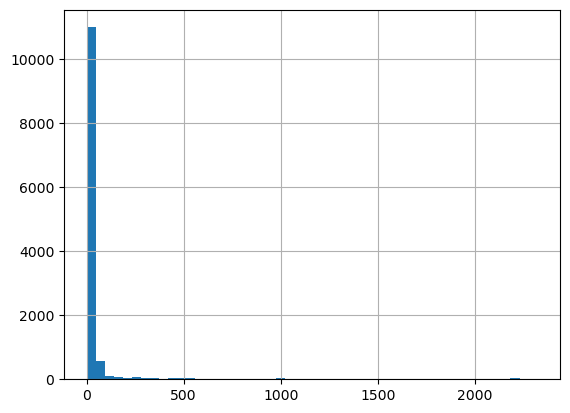

In [6]:
df['standard_value'].hist(bins=50)

## Raw Papp Value Distribution

The histogram below shows the distribution of raw permeability values.  
The dataset is highly right-skewed due to extreme outlier values

<Axes: >

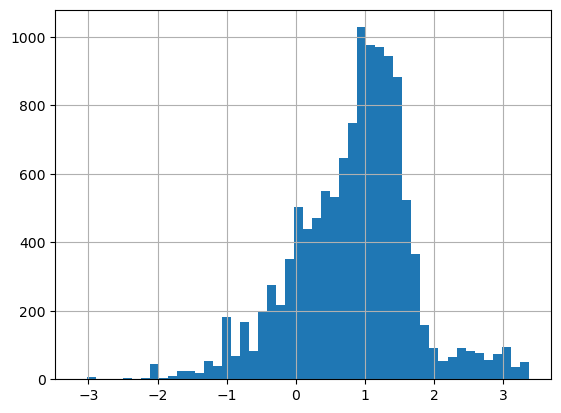

In [7]:
df['log_papp'].hist(bins=50)

## SMILES Length Analysis

The length of SMILES strings is analyzed to understand molecular complexity and dataset diversity.

In [8]:
df['smiles_length'] = df['canonical_smiles'].apply(len)

df['smiles_length'].describe()

count    12290.000000
mean        60.022132
std         25.291839
min          9.000000
25%         46.000000
50%         56.000000
75%         68.000000
max        585.000000
Name: smiles_length, dtype: float64

## SMILES Length Histogram

The length of SMILES strings is analyzed to understand molecular complexity and dataset diversity.

<Axes: >

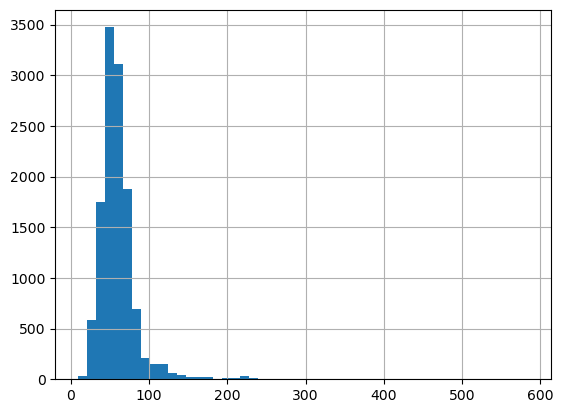

In [9]:
df['smiles_length'].hist(bins=50)

## Duplicate Molecule Handling

Duplicate molecules were identified using canonical SMILES and merged by averaging permeability values.

In [16]:
df.duplicated(subset='canonical_smiles').sum()

0

In [19]:
df_avg = df.groupby('canonical_smiles', as_index=False).agg({
    'standard_value': 'mean'
})

## Outlier Analysis

This section investigates molecules with extremely high or low permeability values.

In [21]:
import numpy as np

df_avg['log_papp'] = np.log10(df_avg['standard_value'])

In [22]:
df_avg.sort_values('log_papp', ascending=False).head(10)

,canonical_smiles,standard_value,log_papp
2236,CCCCCCc1ccc(C(=O)CCN(C)C)cc1,2323.0,3.366049
2220,CCCCCCSc1ccc(C(=O)CCN2CCN(C(C)=O)CC2)c(Cl)c1Cl,2300.0,3.361728
2159,CCCCCCOc1ccc(C(=O)CCN2CCN(C)CC2)cc1,2300.0,3.361728
10985,O=C(Nc1ccc([N+](=O)[O-])cc1Cl)c1cc(Cl)ccc1NS(=...,2250.0,3.352183
8620,Cc1noc(C)c1-c1ccc2nc(-c3cnn(CCO)c3)nc(N3CCOCC3...,2204.0,3.343212
1994,CCCC(=O)N1CCC(N(Cc2ccccc2)C(=O)Nc2cccc(C(F)(F)...,2200.0,3.342423
11021,O=C(Nc1cccc(C(F)(F)F)c1)N(Cc1ccccc1)C1CCN(Cc2c...,2200.0,3.342423
2420,CCCN1CCC(N(CC2CCCCC2)C(=O)Nc2cccc(C(F)(F)F)c2)CC1,2200.0,3.342423
2424,CCCN1CCC(N(Cc2cc(F)cc(C(F)(F)F)c2)C(=O)Nc2cccc...,2200.0,3.342423
2425,CCCN1CCC(N(Cc2ccc3c(c2)OCO3)C(=O)Nc2cccc(C(F)(...,2200.0,3.342423


In [23]:
df_avg.sort_values('log_papp').head(10)

,canonical_smiles,standard_value,log_papp
9157,Cn1cccc1C(=O)N1CCN(C(=O)Nc2ccc(N3CCC(C(=O)N4CC...,0.000700,-3.154902
550,CC(=O)Nc1ccc(Nc2ncnc(N[C@@H](CC(C)C)C(=O)O)n2)cc1,0.001000,-3.000000
5785,COc1ccc2nc(C)cc(OCC(=O)Nc3ccc(N4CCC(c5ccccc5)C...,0.001000,-3.000000
11229,O=C(O)c1c(CN2CCCOCC2)cccc1Nc1c(Cl)cc(-c2nnn[nH...,0.001000,-3.000000
3218,CC[C@H](C)[C@@H]([C@@H](CC(=O)N1CCC[C@H]1[C@H]...,0.001000,-3.000000
3215,CC[C@H](C)[C@@H]([C@@H](CC(=O)N1CCC[C@H]1[C@H]...,0.001000,-3.000000
9979,NCCOCCOCC(=O)N1CCN(C(=O)c2cc(Cc3n[nH]c(=O)c4cc...,0.001190,-2.924453
4441,CNc1nc2nc3c1[nH]c(=O)n3Cc1cccc(c1)OCCNC(=O)CO2,0.002000,-2.698970
5290,COc1cc2c(cc1OC)CN(CCc1ccc(-n3nnc(-c4cc(OC)c(OC...,0.002137,-2.670094
2901,CCOC(=O)c1cc2ccc(OC)cc2o1,0.002470,-2.607303
